# 4 – Model Evaluation
This notebook performs full evaluation on the final Random Forest model.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib


## Load Clean Data

In [2]:
df = pd.read_csv("../dataset/clean.csv")
X = df.drop("Default", axis=1)
y = df["Default"]
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,True,False,False,False,False,False,False


## Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scaling Numerical Features

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Random Forest Model

In [5]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, max_features='sqrt'
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
acc

0.8849226551791658

## Confusion Matrix

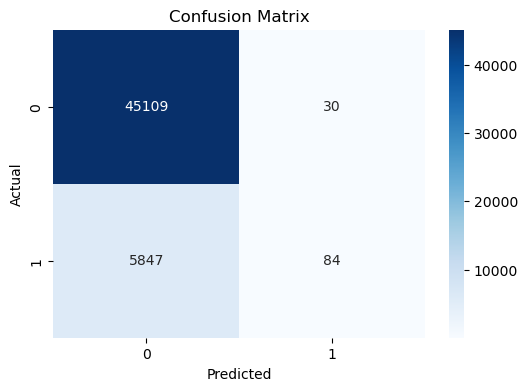

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.74      0.01      0.03      5931

    accuracy                           0.88     51070
   macro avg       0.81      0.51      0.48     51070
weighted avg       0.87      0.88      0.83     51070



## ROC Curve & AUC Score

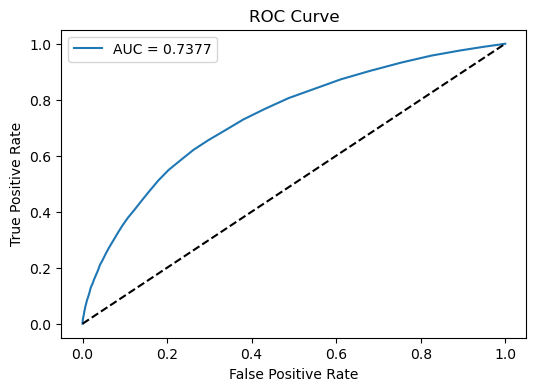

0.7377478746787461

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

auc

## Feature Importance

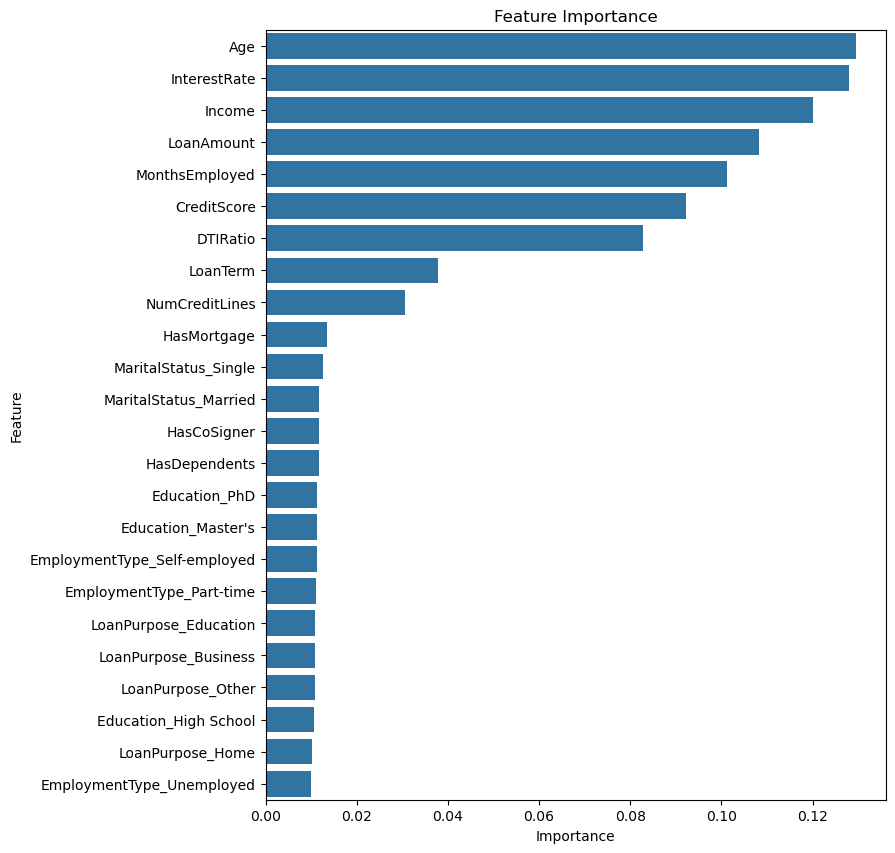

In [9]:
importances = rf.feature_importances_
fi = pd.DataFrame({"Feature": X.columns, "Importance": importances})
fi = fi.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x="Importance", y="Feature", data=fi)
plt.title("Feature Importance")
plt.show()

## Save Final Model & Scaler

In [10]:
joblib.dump(rf, "../model/final_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
print("Model & Scaler saved successfully!")

Model & Scaler saved successfully!
